<a href="https://colab.research.google.com/github/sonia-rafique/Internship-DataScience-Tasks./blob/main/Task-04/Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

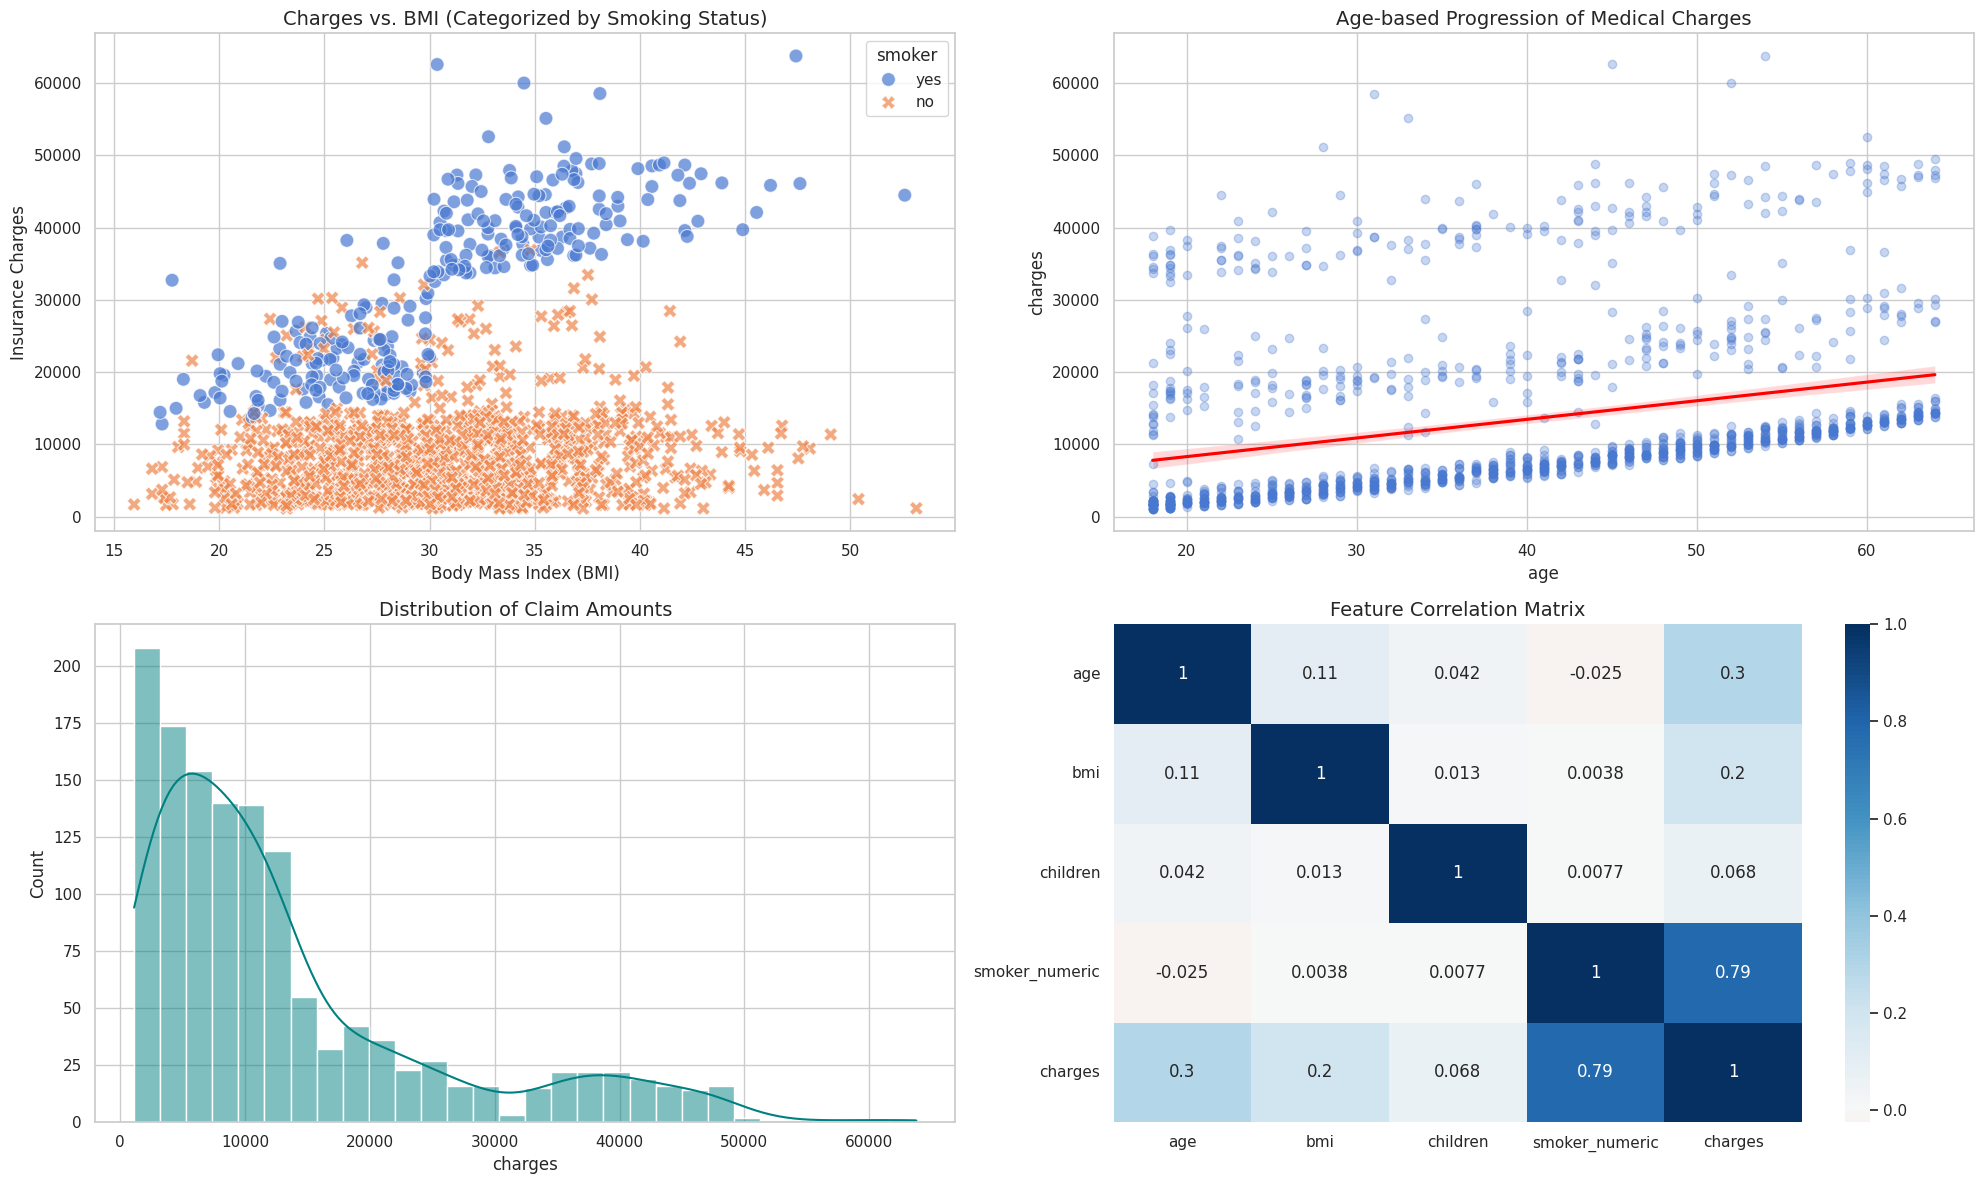

------------------------------
MODEL PERFORMANCE METRICS:
Mean Absolute Error (MAE): $4,213.48
Root Mean Squared Error (RMSE): $5,829.17
R-squared Score: 0.7811
------------------------------


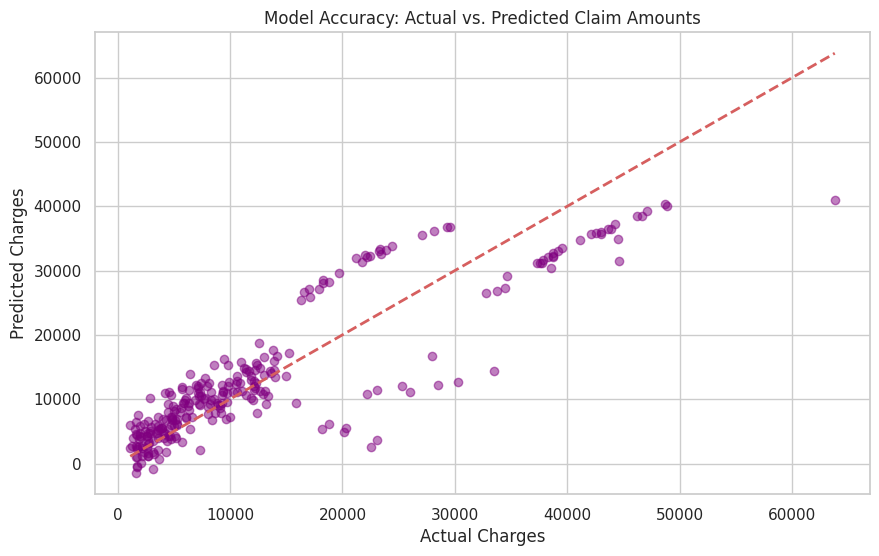

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. DATA LOADING & PREPARATION
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted")


df = pd.read_csv('insurance.csv')

# Encoding categorical variables
# We use 'smoker' as a primary feature; converting to 0 and 1
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex_numeric'] = df['sex'].map({'female': 0, 'male': 1})

# Creating dummy variables for regions
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (VISUALIZATION)
# ---------------------------------------------------------
plt.figure(figsize=(20, 12))

# Plot 1: The Impact of Smoking & BMI on Charges
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='smoker', s=100, alpha=0.7)
plt.title('Charges vs. BMI (Categorized by Smoking Status)', fontsize=14)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Insurance Charges')

# Plot 2: Age vs. Charges (The "Layers" of Insurance)
plt.subplot(2, 2, 2)
sns.regplot(data=df, x='age', y='charges', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Age-based Progression of Medical Charges', fontsize=14)

# Plot 3: Distribution of Charges
plt.subplot(2, 2, 3)
sns.histplot(df['charges'], kde=True, color='teal')
plt.title('Distribution of Claim Amounts', fontsize=14)

# Plot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
corr = df[['age', 'bmi', 'children', 'smoker_numeric', 'charges']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu', center=0)
plt.title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. MODEL TRAINING
# ---------------------------------------------------------
# Define Features (X) and Target (y)
X = df[['age', 'bmi', 'children', 'smoker_numeric', 'sex_numeric']]
y = df['charges']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# 4. EVALUATION & ERROR ANALYSIS
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"MODEL PERFORMANCE METRICS:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")
print("-" * 30)

# 5. VISUALIZING ACTUAL VS. PREDICTED
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Model Accuracy: Actual vs. Predicted Claim Amounts')
plt.show()

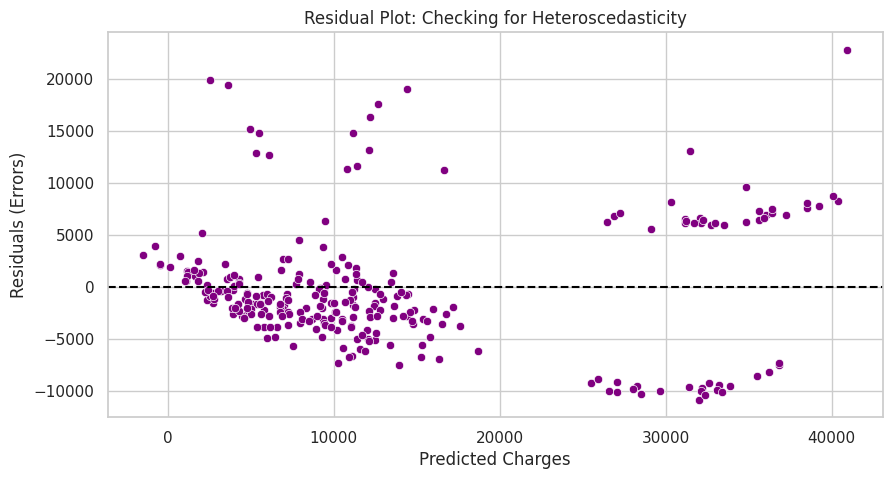

In [ ]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot: Checking for Heteroscedasticity')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Errors)')
plt.show()